In [ ]:
import math
import numpy
import scipy
import matplotlib.pyplot as plt

Я попробую протестировать формулу Байеса, и в целом "поиграю" с Байесовскими вероятностями


Начинаем эксперименты. Вводи 1 для УСПЕХА и 0 для ПРОВАЛА.
Введи 'stop' для завершения.



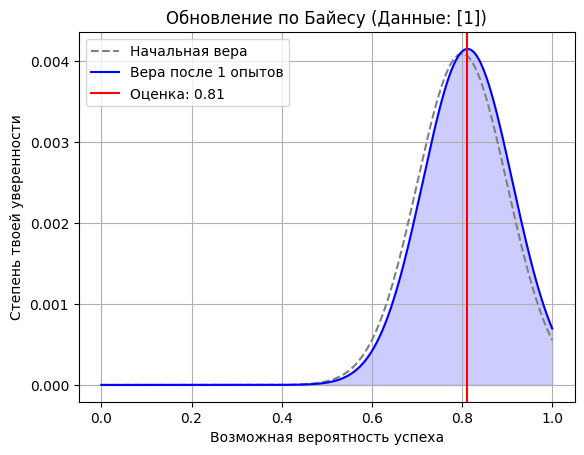

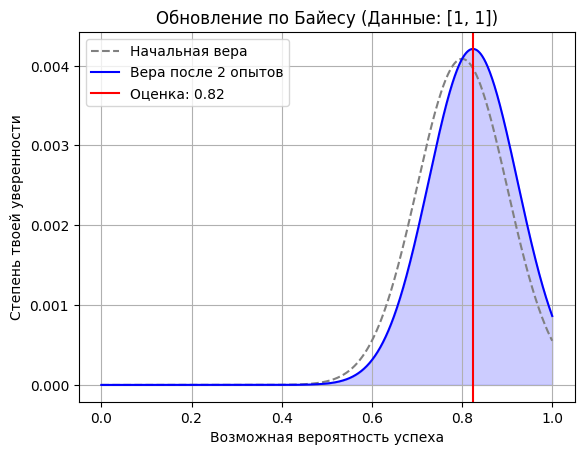

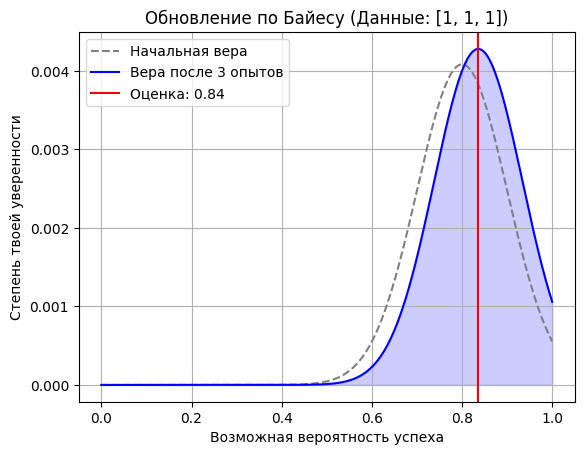

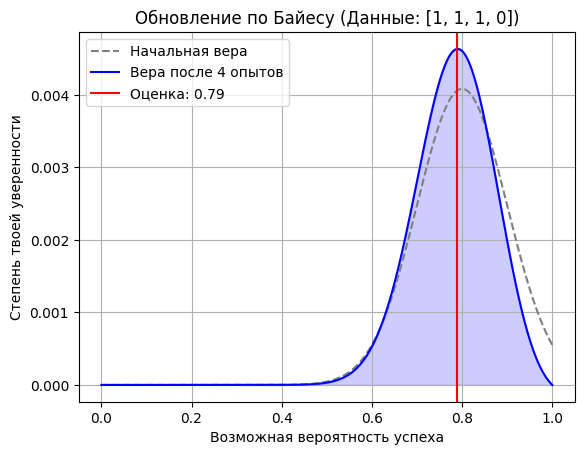

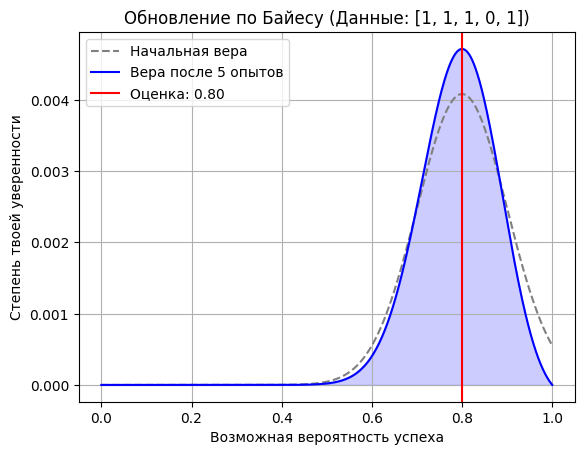

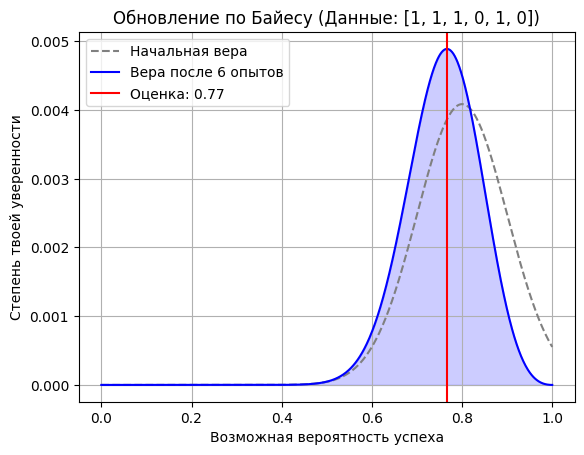

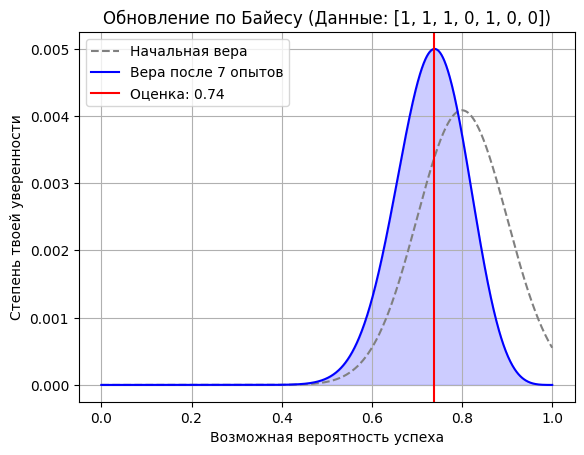

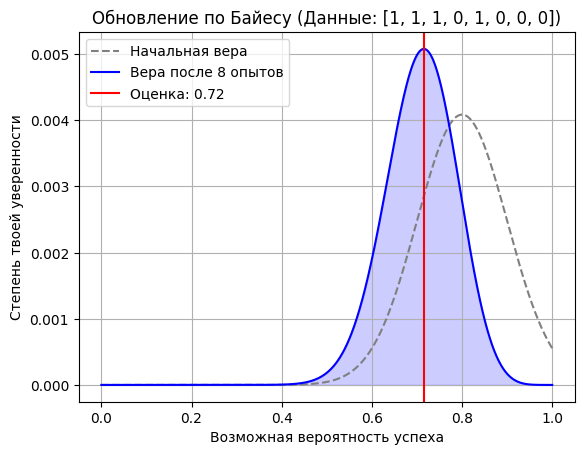

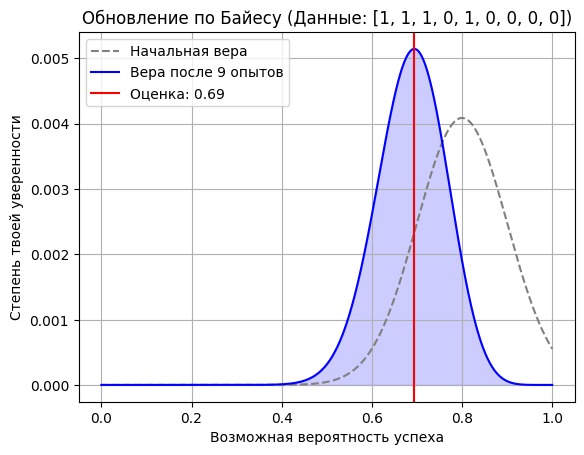

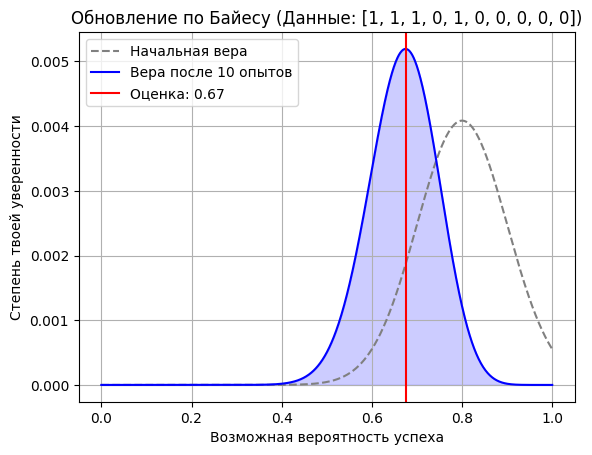

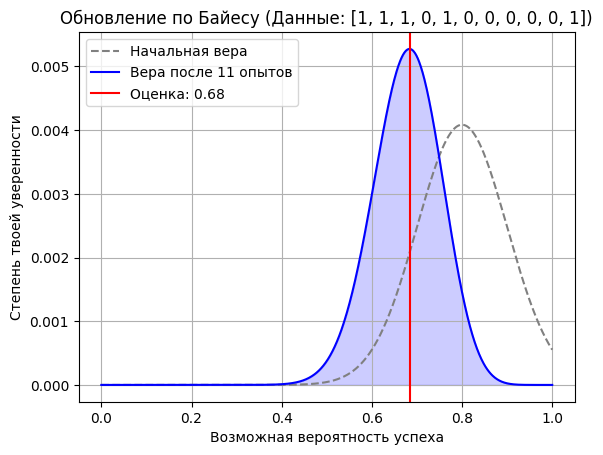

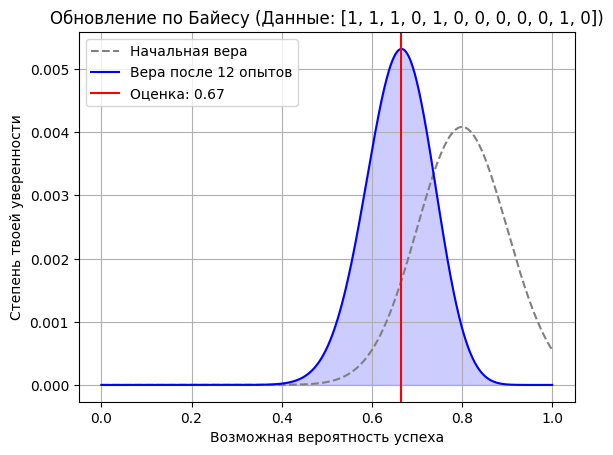

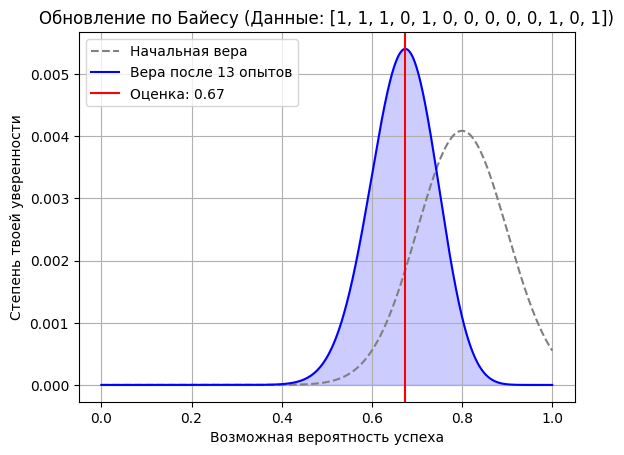

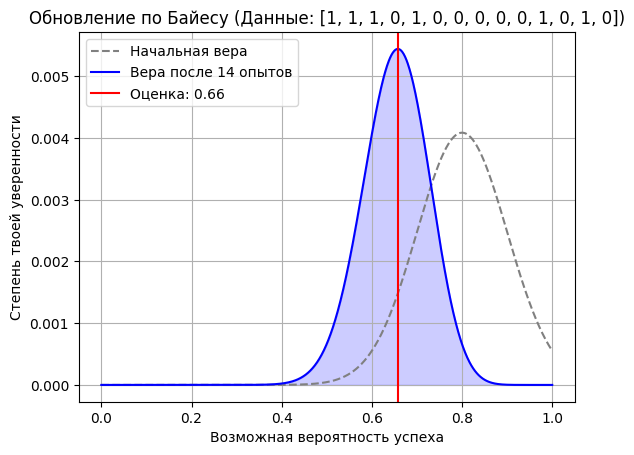

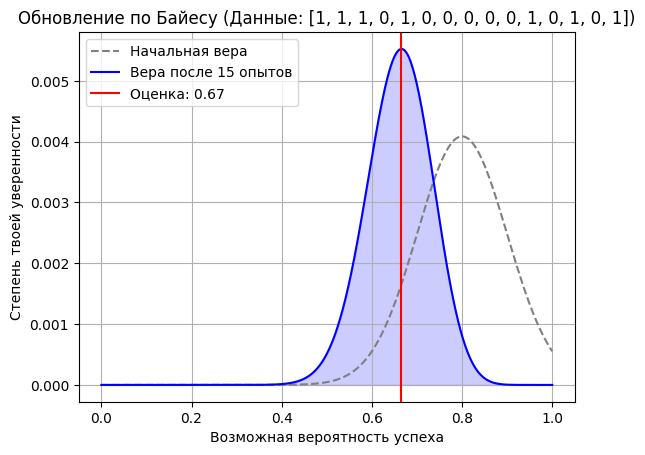

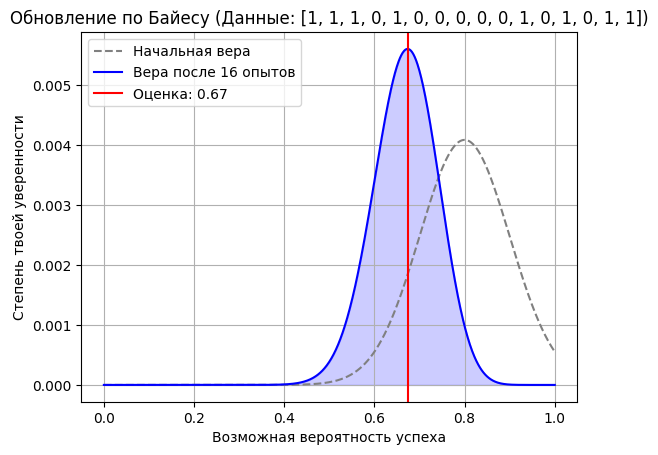

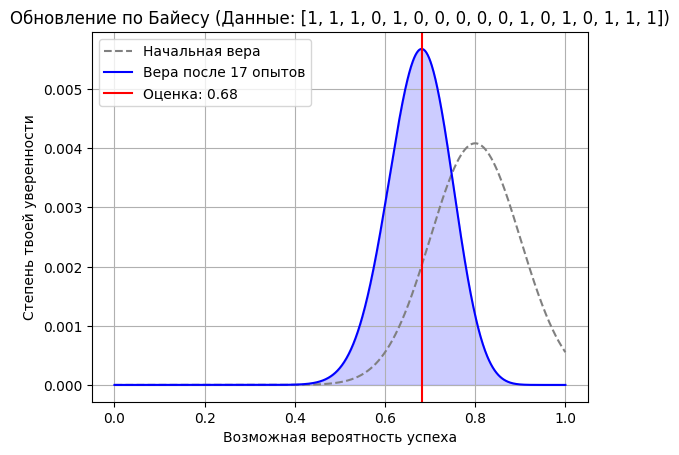

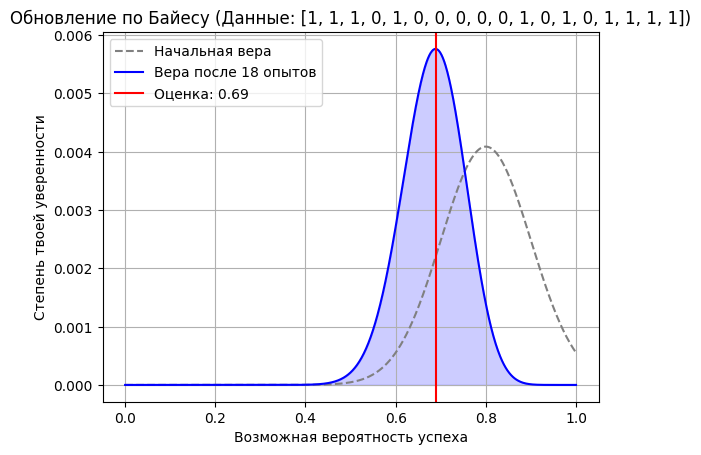

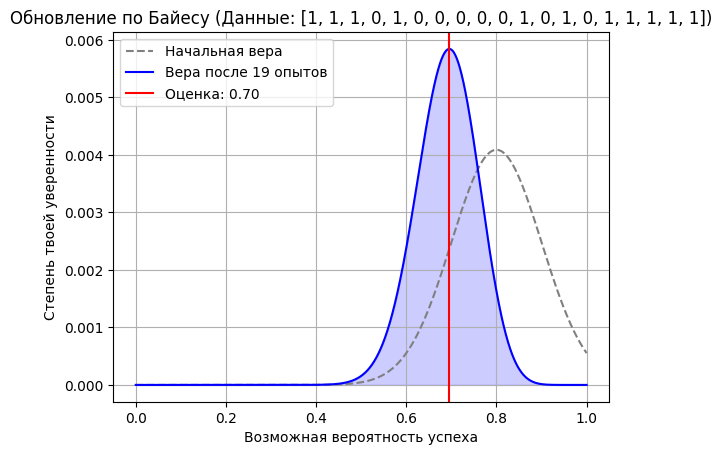

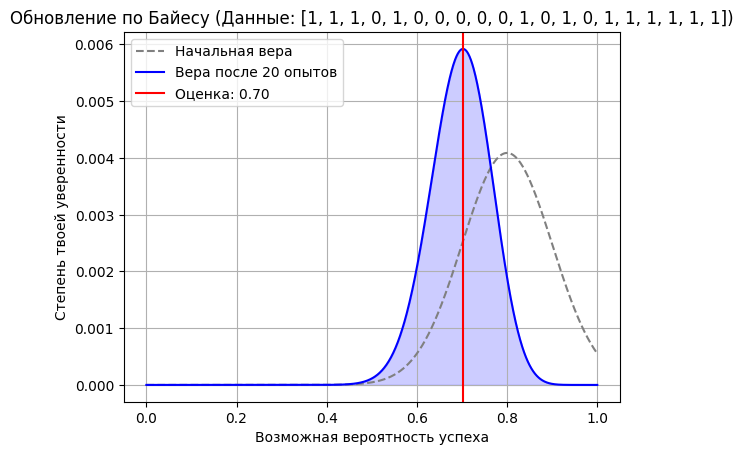

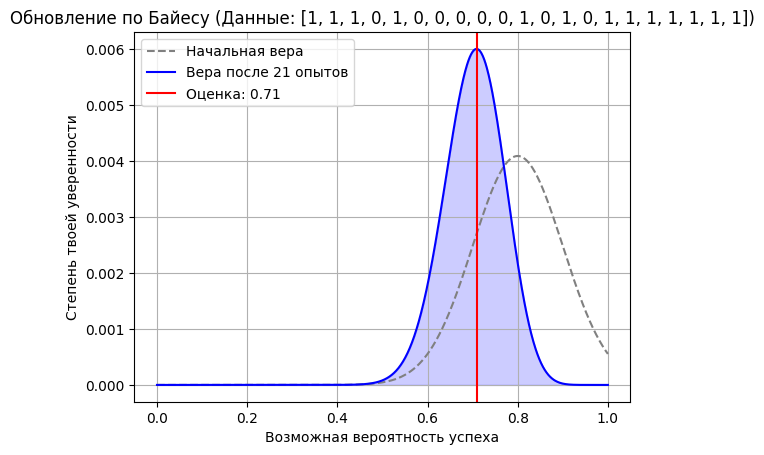

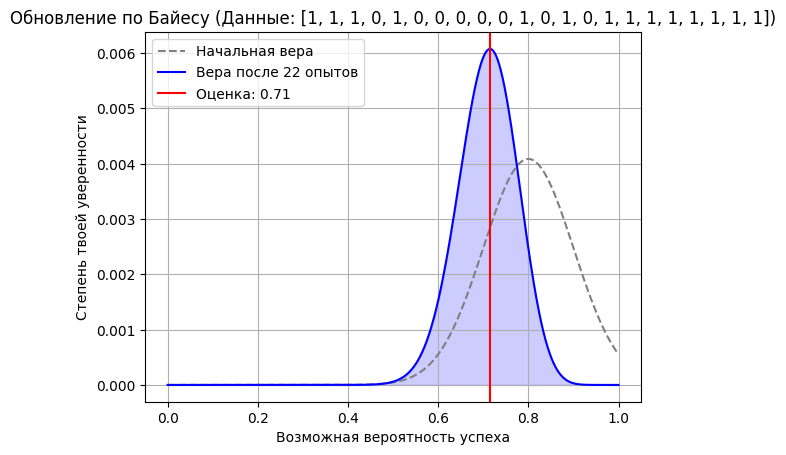

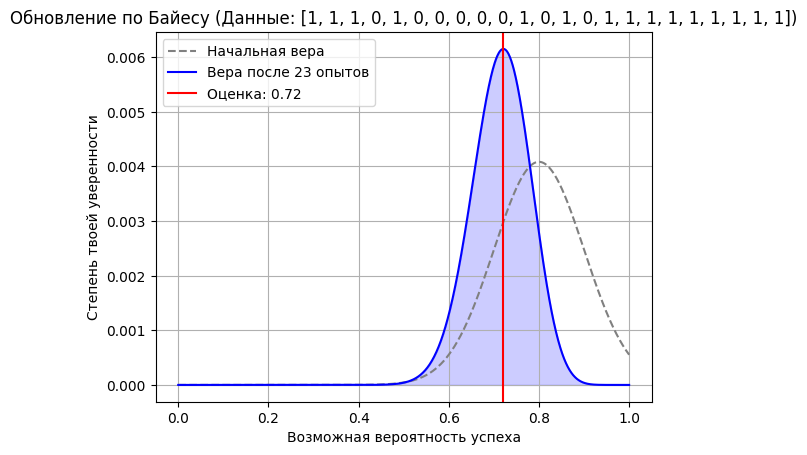


Итог: твоя наиболее вероятная оценка теперь: 0.721


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def bayes_simulation():
    # 1. СОЗДАЕМ ГИПОТЕЗЫ
    # Мы делим отрезок от 0 до 1 на 1000 частей. 
    # Каждая точка - это гипотеза об истинной вероятности.
    hypotheses = np.linspace(0, 1, 1000)
    
    # 2. ЗАДАЕМ НАЧАЛЬНУЮ ВЕРУ (Prior)
    # Давай создадим "горб" вокруг твоей веры (например, 0.6)
    my_belief = float(input("Введи свою изначальную веру (от 0 до 1): "))
    strength = 10 # Насколько ты упрям в своей вере (чем выше, тем уже пик)
    
    # Используем нормальное распределение для инициализации "веры"
    prior = np.exp(-0.5 * ((hypotheses - my_belief) / (1/strength))**2)
    prior /= prior.sum() # Нормализация, чтобы сумма вероятностей была 1

    print("\nНачинаем эксперименты. Вводи 1 для УСПЕХА и 0 для ПРОВАЛА.")
    print("Введи 'stop' для завершения.\n")

    current_prior = prior.copy()
    history = []

    while True:
        user_input = input(f"Эксперимент {len(history)+1} (1/0/stop): ").lower()
        
        if user_input == 'stop':
            break
        if user_input not in ['0', '1']:
            print("Пожалуйста, вводи только 1, 0 или stop.")
            continue
            
        outcome = int(user_input)
        history.append(outcome)

        # 3. ПОЛНАЯ ФОРМУЛА БАЙЕСА
        # Likelihood: вероятность получить такой исход при каждой гипотезе
        if outcome == 1:
            likelihood = hypotheses # Шанс успеха равен самому значению гипотезы
        else:
            likelihood = 1 - hypotheses # Шанс провала
            
        # P(A|B) = [P(B|A) * P(A)] / P(B)
        # Числитель:
        unnormalized_posterior = likelihood * current_prior
        
        # Знаменатель P(B): сумма всех возможных исходов (нормализация)
        evidence = unnormalized_posterior.sum()
        
        # Финальный результат:
        posterior = unnormalized_posterior / evidence
        
        # Обновляем: наше нынешнее "после" становится "до" для следующего шага
        current_prior = posterior

        # Визуализация
        plt.clf()
        plt.plot(hypotheses, prior, label='Начальная вера', linestyle='--', color='gray')
        plt.plot(hypotheses, posterior, label=f'Вера после {len(history)} опытов', color='blue')
        plt.fill_between(hypotheses, 0, posterior, alpha=0.2, color='blue')
        
        most_likely = hypotheses[np.argmax(posterior)]
        plt.axvline(most_likely, color='red', label=f'Оценка: {most_likely:.2f}')
        
        plt.title(f"Обновление по Байесу (Данные: {history})")
        plt.xlabel("Возможная вероятность успеха")
        plt.ylabel("Степень твоей уверенности")
        plt.legend()
        plt.grid(True)
        plt.pause(0.1)
        plt.show(block=False)

    print(f"\nИтог: твоя наиболее вероятная оценка теперь: {hypotheses[np.argmax(current_prior)]:.3f}")
    plt.show()

if __name__ == "__main__":
    bayes_simulation()